# Cube Burst Explorer

Interactive analysis of DSA-110 GPU image-cube dumps (the `dump_all_gpus` NPZ products),
for either an auto-triggered **candidate** or a **manually triggered dump**.

Given an event (e.g. an injection candidate `260602drxx`) or an explicit set of cube
`.npz` files, it produces three diagnostics, all anchored on the detector's predicted
burst (DM, sky pixel, time):

1. **Image time-series** — 10 sky cutouts centered on the burst, with tunable pixel
   extent and time integration. Predicted location and brightest pixel are marked.
2. **Multi-DM light curves** — total power at the brightest pixel at 10 DM trials,
   normalized to sigma against an off-burst baseline, time-smoothable. Burst time marked.
3. **DM-time waterfall** — at the brightest pixel, with tunable time/DM integration.
   Detected DM and time are marked.

**Data model** (see `src/dsart/dump/cube_dump.py`, `src/dsart/coinc/plotter.py`):
- Each cube NPZ holds `cube[t_det, n_fdm, n_grid, n_grid]` float16 — axes are
  (time search-samples, fine-DM trial, l-pixel, m-pixel). Production: `(192, 34, 256, 256)`.
- 8 cubes per event (4 search nodes x 2 GPU halves); each half owns one coarse DM with
  `n_fdm` fine trials. The burst lives in the cube matching the peak C1 row's `(node, half)`.
- Search-sample period ~1.048576 ms; pixel scale ~`1.5e-4` rad/pix (derived from the CSV).
- Detection metadata: `Level2/C1_window_<event>.csv` (per-candidate rows) and
  `Level3/<event>.json` (cluster summary). The cube's `event_specnum_start` is the dump
  *key*, not sample-0, so the **burst time is the argmax of the DM light curve** at the
  detected pixel (mirrors the production plotter).

> Run with the **casa38** kernel.

In [20]:
# =====================================================================
# CONFIGURATION  -- edit this cell, then Run All
# =====================================================================

# --- What to analyze -------------------------------------------------
# Option A: an archived event by name (candidate or manual dump).
EVENT       = "260602zkqz"                       # e.g. "260602drxx" or "dumpnow_xxxxxxxx"
ARCHIVE_ROOT = "/dataz/dsa110/candidates"        # per-event archive tree on h23

# Option B: analyze explicit cube file(s) instead of an event name.
#   Set CUBE_PATHS to a list of .npz paths (or a single cubes/ dir) to
#   override Option A. Leave empty ([]) to use EVENT/ARCHIVE_ROOT.
CUBE_PATHS = []   # e.g. ["/dataz/dsa110/candidates/260602drxx/cubes/cube_s2_g0_10562021.npz"]

# Force a specific (search_node_id, gpu_half) cube. None => auto (cube
# matching the peak detection row; falls back to first available).
FORCE_NODE_HALF = None   # e.g. (2, 0)

# --- Manual detection override (for dumps with no C1 CSV, or to retarget) ---
# Any value left as None is taken from the detector metadata when present.
MANUAL_FDM    = None   # fine-DM trial index into cube axis 1 (0..n_fdm-1)
MANUAL_LPIX   = None   # predicted l pixel (cube axis 2)
MANUAL_MPIX   = None   # predicted m pixel (cube axis 3)
MANUAL_TBURST = None   # burst time sample index (0..t_det-1)

# --- Plot 1: image time-series --------------------------------------
N_IMAGES          = 10     # number of time frames
IMG_EXTENT_PIX    = 24     # half-size of the sky cutout (pixels) -> (2*ext+1)^2
IMG_T_INTEGRATE   = 2      # samples averaged per frame
IMG_FRAME_STRIDE  = None   # samples between frame centers; None => == IMG_T_INTEGRATE

# --- Brightest-pixel search -----------------------------------------
BRIGHT_SEARCH_PIX = 8      # half-window (pixels) around predicted loc to find the peak pixel

# --- Plot 2: multi-DM light curves ----------------------------------
N_DMS             = 10     # number of DM trials to show
DM_SELECT         = "centered"   # "centered" (around detected) or "spread" (across all trials)
LC_SMOOTH_SAMPLES = 1      # boxcar smoothing width (samples); 1 => none
LC_BASELINE_GUARD = 12     # samples on each side of the burst excluded from the noise baseline

# --- Plot 3: DM-time waterfall --------------------------------------
WF_ALL_CUBES      = True   # combine all 8 cubes -> full DM range (vs burst cube only)
WF_DM_MIN         = None   # lower DM bound (pc/cc) for the waterfall; None => auto/full
WF_DM_MAX         = None   # upper DM bound (pc/cc); None => auto/full
WF_T_INTEGRATE    = 1      # time rebin factor
WF_DM_INTEGRATE   = 1      # DM rebin factor
WF_SIGMA          = True   # normalize each DM row to sigma vs off-burst baseline

# DM plan: maps each cube's (node, half) -> its absolute fine-DM values.
# Needed to stitch all cubes into one full-range DM axis. Fetched from a
# search node; rebuild with tools/build_dm_plan.py if absent.
DM_PLAN_PATH       = "/home/ubuntu/data/dm_plans/dm_plan_N8_dmmin100_tol1.6_v2.npz"
N_HALVES_PER_NODE  = 2     # GPU halves per search node (owner = 2*node_rank + half)

# --- Misc ------------------------------------------------------------
SAMPLE_PERIOD_US_FALLBACK = 1048.576   # search-sample period if not stored in NPZ
CELL_RAD_FALLBACK         = 1.5e-4     # rad/pixel if it can't be derived from the CSV
CMAP = "viridis"

In [21]:
# =====================================================================
# Imports + helpers (no dsart dependency; self-contained)
# =====================================================================
import ast
import csv
import glob
import json
import re
import struct
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

_CUBE_RE = re.compile(r"cube_s(?P<sid>\d+)_g(?P<g>\d+)_(?P<specnum>\d+)\.npz$")


def mmap_npz_array(npz_path, key="cube"):
    """Memory-map an uncompressed array inside an .npz (np.savez, ZIP_STORED).

    Avoids copying the ~855 MB cube into RAM. Mirrors the production
    plotter's loader (src/dsart/coinc/plotter.py::_mmap_npz_array).
    """
    npz_path = str(npz_path)
    with zipfile.ZipFile(npz_path) as zf:
        info = zf.getinfo(f"{key}.npy")
    if info.compress_type != zipfile.ZIP_STORED:
        raise ValueError(f"{key}.npy is compressed; cannot mmap")
    with open(npz_path, "rb") as fh:
        fh.seek(info.header_offset)
        local = fh.read(30)
        if local[:4] != b"PK\x03\x04":
            raise ValueError("bad zip local header magic")
        name_len = struct.unpack("<H", local[26:28])[0]
        extra_len = struct.unpack("<H", local[28:30])[0]
        data_start = info.header_offset + 30 + name_len + extra_len
        fh.seek(data_start)
        magic = fh.read(10)
        if magic[:6] != b"\x93NUMPY":
            raise ValueError("missing NPY magic")
        major = magic[6]
        if major == 1:
            hl = struct.unpack("<H", magic[8:10])[0]
            npy_prefix = 10 + hl
        else:
            hl_ext = fh.read(2)
            hl = struct.unpack("<I", magic[8:10] + hl_ext)[0]
            npy_prefix = 12 + hl
        header_str = fh.read(hl).decode("latin1")
    hdr = ast.literal_eval(header_str)
    dtype = np.dtype(hdr["descr"])
    shape = tuple(hdr["shape"])
    order = "F" if bool(hdr.get("fortran_order", False)) else "C"
    return np.memmap(npz_path, dtype=dtype, shape=shape, order=order,
                     mode="r", offset=data_start + npy_prefix)


def npz_scalar(npz_path, key, default=None):
    """Read a 0-d scalar field from an NPZ (small fields only)."""
    try:
        with np.load(npz_path, allow_pickle=False) as d:
            if key in d.files:
                return np.asarray(d[key]).item()
    except Exception:
        pass
    return default


def read_c1_window_csv(archive_root, event):
    p = Path(archive_root) / event / "Level2" / f"C1_window_{event}.csv"
    if not p.is_file():
        return []
    with open(p, newline="") as fh:
        return list(csv.DictReader(fh))


def read_level3(archive_root, event):
    p = Path(archive_root) / event / "Level3" / f"{event}.json"
    if not p.is_file():
        return {}
    with open(p) as fh:
        return json.load(fh)


def peak_row_from_csv(rows):
    """Highest-SNR C1 row = the detector's burst peak."""
    best, best_snr = None, -np.inf
    for r in rows:
        try:
            s = float(r["snr"])
        except (KeyError, TypeError, ValueError):
            continue
        if s > best_snr:
            best_snr, best = s, r
    return best


def fit_dm_axis(rows, n_fdm):
    """Linear fit fine_dm_idx -> dm_pc_cc from the CSV rows.

    Returns (dm_axis[n_fdm], known: bool). The fine-DM grid is linear in
    the cube's axis-1 index, so two distinct rows pin the whole axis.
    """
    pairs = {}
    for r in rows:
        try:
            pairs[int(r["fine_dm_idx"])] = float(r["dm_pc_cc"])
        except (KeyError, TypeError, ValueError):
            continue
    if len(pairs) >= 2:
        xs = np.array(sorted(pairs), dtype=float)
        ys = np.array([pairs[int(x)] for x in xs], dtype=float)
        slope, intercept = np.polyfit(xs, ys, 1)
        return intercept + slope * np.arange(n_fdm), True
    return np.arange(n_fdm, dtype=float), False


def derive_cell_rad(rows, fallback):
    """rad/pixel from any CSV row (l_rad/l_pix), median over rows."""
    vals = []
    for r in rows:
        try:
            lp, lr = float(r["l_pix"]), float(r["l_rad"])
            mp, mr = float(r["m_pix"]), float(r["m_rad"])
        except (KeyError, TypeError, ValueError):
            continue
        if lp:
            vals.append(lr / lp)
        if mp:
            vals.append(mr / mp)
    return float(np.median(vals)) if vals else float(fallback)


def resolve_cube_paths():
    """Return a list of cube .npz Paths from CUBE_PATHS or EVENT."""
    out = []
    if CUBE_PATHS:
        for c in CUBE_PATHS:
            cp = Path(c)
            if cp.is_dir():
                out += sorted(cp.glob("cube_s*_g*_*.npz"))
            elif cp.is_file():
                out.append(cp)
    else:
        d = Path(ARCHIVE_ROOT) / EVENT / "cubes"
        out = sorted(d.glob("cube_s*_g*_*.npz"))
    return out


def cube_node_half(path):
    m = _CUBE_RE.search(Path(path).name)
    return (int(m.group("sid")), int(m.group("g"))) if m else (None, None)


def choose_burst_cube(paths, peak):
    """Pick the cube owning the burst (peak's node/half), else first."""
    if FORCE_NODE_HALF is not None:
        for p in paths:
            if cube_node_half(p) == tuple(FORCE_NODE_HALF):
                return p
    if peak is not None:
        want = (int(peak["search_node_id"]), int(peak["gpu_half"]))
        for p in paths:
            if cube_node_half(p) == want:
                return p
    return paths[0] if paths else None


def boxcar(x, w):
    """Same-length boxcar smoothing (mean over w samples)."""
    w = int(max(1, w))
    if w == 1:
        return np.asarray(x, dtype=float)
    k = np.ones(w, dtype=float) / w
    return np.convolve(np.asarray(x, dtype=float), k, mode="same")


def baseline_sigma(lc, t_burst, guard):
    """Normalize a light curve to sigma using off-burst samples.

    mean/std are computed over samples >= guard away from t_burst.
    """
    lc = np.asarray(lc, dtype=float)
    n = lc.size
    mask = np.ones(n, dtype=bool)
    lo, hi = max(0, t_burst - guard), min(n, t_burst + guard + 1)
    mask[lo:hi] = False
    if mask.sum() < 8:           # too little baseline -> use the whole series
        mask[:] = True
    mu = np.nanmean(lc[mask])
    sd = np.nanstd(lc[mask])
    if not np.isfinite(sd) or sd == 0:
        sd = 1.0
    return (lc - mu) / sd


def rebin2d(a, fy, fx, reduce=np.mean):
    """Block-rebin a 2-D array by (fy, fx), trimming the remainder."""
    fy, fx = int(max(1, fy)), int(max(1, fx))
    ny = (a.shape[0] // fy) * fy
    nx = (a.shape[1] // fx) * fx
    a = a[:ny, :nx]
    a = a.reshape(a.shape[0] // fy, fy, a.shape[1] // fx, fx)
    return reduce(reduce(a, axis=3), axis=1)


def load_dm_plan(path):
    """Load {fine, coarse, f2c} from a DmPlan NPZ, or None if unavailable."""
    try:
        d = np.load(path)
    except Exception:
        return None
    fk = next((k for k in ("fine_dm", "fine_dm_pc_cm3") if k in d.files), None)
    ck = next((k for k in ("coarse_dm", "coarse_dm_pc_cm3") if k in d.files), None)
    if fk is None or "fine_to_coarse" not in d.files:
        return None
    return {
        "fine": np.asarray(d[fk], dtype=float),
        "coarse": (np.asarray(d[ck], dtype=float) if ck else None),
        "f2c": np.asarray(d["fine_to_coarse"], dtype=int),
    }


def coarse_index_fn(paths, halves_per_node):
    """Map a cube's (node_id, gpu_half) -> coarse-DM index.

    Mirrors build_dm_plan's partition: GPU (s, g) owns coarse index
    `halves_per_node*s + g`, where `s` is the node's rank among the
    distinct search nodes present (sorted). For the production fleet
    nodes [1,2,9,13] -> ranks [0,1,2,3] -> coarse {0/1, 2/3, 4/5, 6/7}.
    """
    nodes = sorted({cube_node_half(p)[0] for p in paths
                    if cube_node_half(p)[0] is not None})
    rank = {n: i for i, n in enumerate(nodes)}
    return (lambda sid, g: halves_per_node * rank[sid] + g), rank


def build_full_dm_time(paths, plan, lpix, mpix, halves_per_node):
    """DM-time slice at pixel (lpix, mpix) stitched across cubes.

    Returns (dms, M) sorted by DM: `dms` length = sum of fine trials,
    `M` shape (n_dm, t_det). DM values come from `plan`; if a cube can't
    be mapped, its rows are labeled NaN (and dropped from the DM axis).
    """
    idx_fn, _ = coarse_index_fn(paths, halves_per_node)
    dms, cols = [], []
    for p in paths:
        sid, g = cube_node_half(p)
        c = mmap_npz_array(p, "cube")
        wf = np.asarray(c[:, :, lpix, mpix], dtype=np.float32)   # (t_det, n_fdm)
        block = np.full(wf.shape[1], np.nan)
        if plan is not None and sid is not None:
            try:
                ci = idx_fn(sid, g)
                b = plan["fine"][plan["f2c"] == ci]
                if len(b) == wf.shape[1]:
                    block = b
            except KeyError:
                pass
        for j in range(wf.shape[1]):
            dms.append(block[j]); cols.append(wf[:, j])
    dms = np.asarray(dms, dtype=float)
    M = np.asarray(cols, dtype=np.float32)         # (n_dm, t_det)
    order = np.argsort(np.where(np.isnan(dms), np.inf, dms))
    return dms[order], M[order]


def rebin_dm_time(dms, M, f_dm, f_t):
    """Rebin (dms, M[n_dm, t_det]) by (f_dm along DM, f_t along time)."""
    f_dm, f_t = int(max(1, f_dm)), int(max(1, f_t))
    if f_t > 1:
        nt = (M.shape[1] // f_t) * f_t
        M = M[:, :nt].reshape(M.shape[0], nt // f_t, f_t).mean(axis=2)
    if f_dm > 1:
        nd = (M.shape[0] // f_dm) * f_dm
        M = M[:nd].reshape(nd // f_dm, f_dm, M.shape[1]).mean(axis=1)
        dms = dms[:nd].reshape(nd // f_dm, f_dm).mean(axis=1)
    return dms, M


def centers_to_edges(c):
    """Cell edges from (possibly non-uniform) centers, for pcolormesh."""
    c = np.asarray(c, dtype=float)
    if c.size == 1:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    mid = 0.5 * (c[1:] + c[:-1])
    return np.concatenate([[c[0] - (mid[0] - c[0])], mid,
                           [c[-1] + (c[-1] - mid[-1])]])


print("helpers loaded")

helpers loaded


In [22]:
# =====================================================================
# Load metadata + burst cube, resolve detector burst & brightest pixel
# =====================================================================
rows = [] if CUBE_PATHS else read_c1_window_csv(ARCHIVE_ROOT, EVENT)
l3 = {} if CUBE_PATHS else read_level3(ARCHIVE_ROOT, EVENT)
peak = peak_row_from_csv(rows)

paths = resolve_cube_paths()
if not paths:
    raise FileNotFoundError("No cube .npz found. Check EVENT/ARCHIVE_ROOT or CUBE_PATHS.")
burst_path = choose_burst_cube(paths, peak)
print(f"cubes found: {len(paths)}  |  burst cube: {Path(burst_path).name}")

cube = mmap_npz_array(burst_path, "cube")          # (t_det, n_fdm, n_grid, n_grid) fp16
t_det, n_fdm, n_grid, _ = cube.shape
sample_period_us = float(npz_scalar(burst_path, "sample_period_us",
                                    SAMPLE_PERIOD_US_FALLBACK))
mjd_start = npz_scalar(burst_path, "mjd_start", None)
print(f"cube shape = {cube.shape}  dtype={cube.dtype}  "
      f"tsamp={sample_period_us/1000:.4f} ms  mjd_start={mjd_start}")

# DM axis (real pc/cc if derivable from CSV, else trial index) + pixel scale.
dm_axis, dm_known = fit_dm_axis(rows, n_fdm)
cell_rad = derive_cell_rad(rows, CELL_RAD_FALLBACK)

# ---- Resolve detected DM trial + predicted sky pixel ----------------
if peak is not None:
    det_fdm  = int(peak["fine_dm_idx"])
    det_lpix = int(peak["l_pix"])
    det_mpix = int(peak["m_pix"])
    det_snr  = float(peak["snr"])
    det_width = int(float(peak["width_samples"]))
    det_source = "C1-window CSV peak"
else:
    det_fdm = det_lpix = det_mpix = None
    det_snr = det_width = None
    det_source = "manual / cube-argmax fallback"

# Manual overrides take precedence.
if MANUAL_FDM  is not None: det_fdm  = int(MANUAL_FDM)
if MANUAL_LPIX is not None: det_lpix = int(MANUAL_LPIX)
if MANUAL_MPIX is not None: det_mpix = int(MANUAL_MPIX)

# Fallback when there is no detection metadata: global waterfall argmax.
if det_fdm is None or det_lpix is None or det_mpix is None:
    wf_full = np.asarray(cube.max(axis=(2, 3)), dtype=np.float32)  # (t_det, n_fdm)
    ft, ff = np.unravel_index(int(np.argmax(wf_full)), wf_full.shape)
    plane = np.asarray(cube[ft, ff], dtype=np.float32)
    bl, bm = np.unravel_index(int(np.argmax(plane)), plane.shape)
    det_fdm = int(ff) if det_fdm is None else det_fdm
    det_lpix = int(bl) if det_lpix is None else det_lpix
    det_mpix = int(bm) if det_mpix is None else det_mpix
    det_source = "cube-argmax fallback (no metadata)"

det_fdm = int(np.clip(det_fdm, 0, n_fdm - 1))
det_lpix = int(np.clip(det_lpix, 0, n_grid - 1))
det_mpix = int(np.clip(det_mpix, 0, n_grid - 1))

# ---- Burst time = argmax of DM light curve at the predicted pixel ---
lc_pred = np.asarray(cube[:, det_fdm, det_lpix, det_mpix], dtype=np.float32)
t_burst = int(np.argmax(lc_pred)) if MANUAL_TBURST is None else int(MANUAL_TBURST)
t_burst = int(np.clip(t_burst, 0, t_det - 1))

# ---- Brightest pixel near the predicted location -------------------
t0 = max(0, t_burst - IMG_T_INTEGRATE // 2)
t1 = min(t_det, t0 + max(1, IMG_T_INTEGRATE))
sel_img = np.asarray(cube[t0:t1, det_fdm], dtype=np.float32).mean(axis=0)  # (n_grid,n_grid)
r0 = max(0, det_lpix - BRIGHT_SEARCH_PIX); r1 = min(n_grid, det_lpix + BRIGHT_SEARCH_PIX + 1)
c0 = max(0, det_mpix - BRIGHT_SEARCH_PIX); c1 = min(n_grid, det_mpix + BRIGHT_SEARCH_PIX + 1)
win = sel_img[r0:r1, c0:c1]
br, bc = np.unravel_index(int(np.argmax(win)), win.shape)
bright_lpix, bright_mpix = int(r0 + br), int(c0 + bc)

det_dm = float(dm_axis[det_fdm])
t_burst_ms = t_burst * sample_period_us / 1000.0

print("\n--- detector burst ---")
print(f"  source            : {det_source}")
print(f"  DM trial (fdm)    : {det_fdm}  ->  DM = "
      f"{det_dm:.2f} {'pc/cc' if dm_known else '(trial index; DM unknown)'}")
print(f"  predicted pixel   : (l={det_lpix}, m={det_mpix})  "
      f"~ (l={det_lpix*cell_rad:.4f}, m={det_mpix*cell_rad:.4f}) rad")
print(f"  brightest pixel   : (l={bright_lpix}, m={bright_mpix})")
print(f"  burst time sample : {t_burst}  (t = {t_burst_ms:.2f} ms in cube)")
if det_snr is not None:
    print(f"  detected SNR/width: {det_snr:.2f} / {det_width} samples")
if l3.get("c2"):
    c2 = l3["c2"]
    print(f"  L3 cluster        : snr_max={c2.get('snr_max')} "
          f"dm_median={c2.get('dm_median')} n_events={c2.get('n_events')} "
          f"class={l3.get('trigger', {}).get('class')}")

# ---- Full DM range: stitch all cubes at the brightest pixel ---------
plan = load_dm_plan(DM_PLAN_PATH)
if WF_ALL_CUBES and len(paths) > 1:
    wf_paths = paths
else:
    wf_paths = [burst_path]
dm_full, M_full = build_full_dm_time(wf_paths, plan, bright_lpix, bright_mpix,
                                     N_HALVES_PER_NODE)
dm_full_known = bool(np.isfinite(dm_full).all()) and plan is not None
if not dm_full_known:
    # No usable DM plan: fall back to the burst cube's CSV-fit DM axis,
    # restricted to that single cube, and label by index where unknown.
    if plan is None:
        print("\n[warn] DM plan not found at DM_PLAN_PATH -> waterfall uses the "
              "burst cube only with its CSV-derived DM axis.")
    dm_full, M_full = (dm_axis.copy(),
                       np.asarray(cube[:, :, bright_lpix, bright_mpix],
                                  dtype=np.float32).T)
    dm_full_known = dm_known

print(f"\nwaterfall: {len(wf_paths)} cube(s), {M_full.shape[0]} DM trials, "
      f"DM range [{np.nanmin(dm_full):.1f} .. {np.nanmax(dm_full):.1f}]"
      f"{' pc/cc' if dm_full_known else ' (trial index)'}")

cubes found: 8  |  burst cube: cube_s2_g1_6808042.npz
cube shape = (192, 34, 256, 256)  dtype=float16  tsamp=1.0486 ms  mjd_start=61193.81178582829

--- detector burst ---
  source            : C1-window CSV peak
  DM trial (fdm)    : 2  ->  DM = 1072.51 pc/cc
  predicted pixel   : (l=171, m=64)  ~ (l=0.0256, m=0.0096) rad
  brightest pixel   : (l=171, m=64)
  burst time sample : 106  (t = 111.15 ms in cube)
  detected SNR/width: 17.30 / 1 samples
  L3 cluster        : snr_max=17.29688 dm_median=1072.506592 n_events=5 class=bright_frb_extragalactic

waterfall: 8 cube(s), 272 DM trials, DM range [100.0 .. 2653.0] pc/cc


## Plot 1 — Image time-series centered on the burst

`N_IMAGES` sky cutouts at the detected DM, each integrating `IMG_T_INTEGRATE` samples,
stepping by `IMG_FRAME_STRIDE` (default = the integration). The burst sample sits in the
middle frame. Cutout half-size is `IMG_EXTENT_PIX`. The predicted location (cyan +) and
the brightest pixel (red x) are marked; a shared color scale is used across frames.

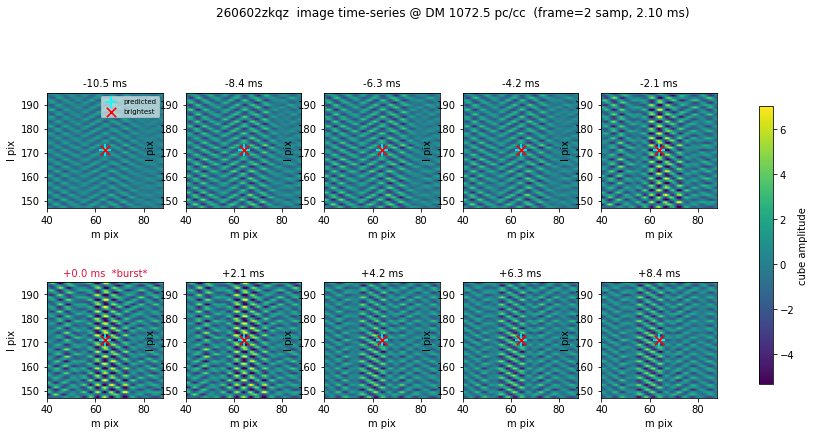

In [23]:
# =====================================================================
# Plot 1: image time-series
# =====================================================================
stride = IMG_T_INTEGRATE if IMG_FRAME_STRIDE is None else int(IMG_FRAME_STRIDE)
ext = int(IMG_EXTENT_PIX)
rr0 = max(0, det_lpix - ext); rr1 = min(n_grid, det_lpix + ext + 1)
cc0 = max(0, det_mpix - ext); cc1 = min(n_grid, det_mpix + ext + 1)

# Frame start samples, centered so the burst lands in the middle frame.
mid = N_IMAGES // 2
frame_starts = [t_burst + (k - mid) * stride - IMG_T_INTEGRATE // 2
                for k in range(N_IMAGES)]

frames, labels = [], []
for fs in frame_starts:
    a = max(0, fs); b = min(t_det, fs + max(1, IMG_T_INTEGRATE))
    if b <= a:
        frames.append(np.full((rr1 - rr0, cc1 - cc0), np.nan, np.float32))
    else:
        frames.append(np.asarray(cube[a:b, det_fdm, rr0:rr1, cc0:cc1],
                                  dtype=np.float32).mean(axis=0))
    dt_ms = (fs + IMG_T_INTEGRATE / 2 - t_burst) * sample_period_us / 1000.0
    labels.append(f"{dt_ms:+.1f} ms")

stack = np.array(frames)
finite = stack[np.isfinite(stack)]
vmin, vmax = np.percentile(finite, [1, 99.7]) if finite.size else (0, 1)

ncol = 5
nrow = int(np.ceil(N_IMAGES / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 3.2 * nrow))
axes = np.atleast_1d(axes).ravel()
pred_xy = (det_mpix - cc0, det_lpix - rr0)        # (x=m, y=l) in cutout coords
bright_xy = (bright_mpix - cc0, bright_lpix - rr0)
im = None
for k, ax in enumerate(axes):
    if k >= N_IMAGES:
        ax.axis("off"); continue
    im = ax.imshow(frames[k], origin="lower", cmap=CMAP, vmin=vmin, vmax=vmax,
                   extent=[cc0, cc1 - 1, rr0, rr1 - 1], aspect="equal")
    ax.scatter(*[[det_mpix], [det_lpix]], marker="+", s=130, c="cyan",
               linewidths=1.6, label="predicted")
    ax.scatter(*[[bright_mpix], [bright_lpix]], marker="x", s=90, c="red",
               linewidths=1.6, label="brightest")
    is_burst = frame_starts[k] <= t_burst < frame_starts[k] + max(1, IMG_T_INTEGRATE)
    ax.set_title(labels[k] + ("  *burst*" if is_burst else ""),
                 fontsize=10, color=("crimson" if is_burst else "black"))
    ax.set_xlabel("m pix"); ax.set_ylabel("l pix")
axes[0].legend(loc="upper right", fontsize=7, framealpha=0.6)
if im is not None:
    fig.colorbar(im, ax=axes[:N_IMAGES].tolist(), shrink=0.8, label="cube amplitude")
fig.suptitle(f"{EVENT}  image time-series @ DM "
             f"{det_dm:.1f}{' pc/cc' if dm_known else ' (trial idx)'}  "
             f"(frame={IMG_T_INTEGRATE} samp, {IMG_T_INTEGRATE*sample_period_us/1000:.2f} ms)",
             fontsize=12, y=1.02)
plt.show()

## Plot 2 — Multi-DM light curves at the brightest pixel

Total power vs time at the brightest pixel for `N_DMS` DM trials (`DM_SELECT`:
`centered` on the detected DM, or `spread` across all trials). Each curve is normalized to
**sigma** using an off-burst baseline (samples >= `LC_BASELINE_GUARD` from the burst) and
boxcar-smoothed by `LC_SMOOTH_SAMPLES`. Curves are offset vertically; the detected DM is
bold and the burst time is the dashed line.

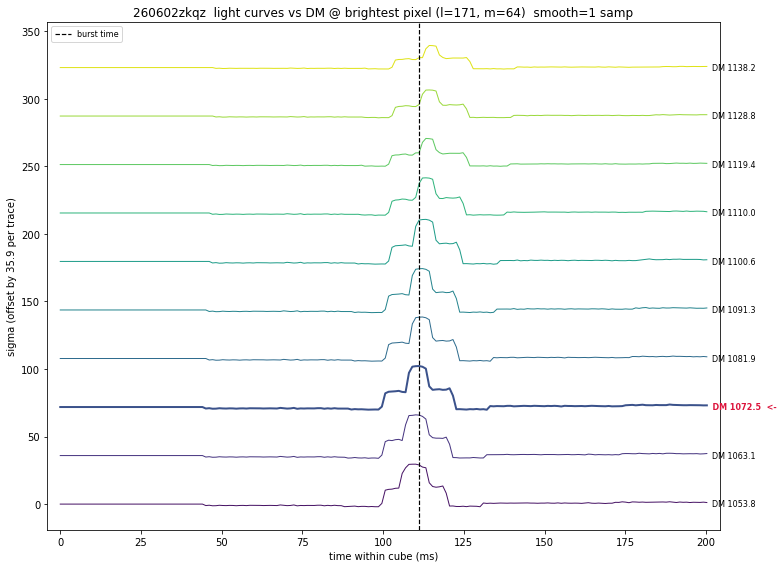

peak sigma at detected DM (trial 2): 30.4 sigma at t=111.15 ms


In [24]:
# =====================================================================
# Plot 2: multi-DM light curves at the brightest pixel (sigma units)
# =====================================================================
n_dms = int(min(N_DMS, n_fdm))
if DM_SELECT == "spread":
    fdm_idxs = np.unique(np.linspace(0, n_fdm - 1, n_dms).round().astype(int))
else:  # centered on the detected DM trial
    start = int(np.clip(det_fdm - n_dms // 2, 0, max(0, n_fdm - n_dms)))
    fdm_idxs = np.arange(start, start + n_dms)
fdm_idxs = np.clip(fdm_idxs, 0, n_fdm - 1)

t_ms = np.arange(t_det) * sample_period_us / 1000.0

# Pull all needed light curves in one slice: (t_det, len(fdm_idxs)).
lcs = np.asarray(cube[:, fdm_idxs, bright_lpix, bright_mpix], dtype=np.float32)
sig = np.stack([baseline_sigma(lcs[:, j], t_burst, LC_BASELINE_GUARD)
                for j in range(lcs.shape[1])], axis=1)
sig = np.stack([boxcar(sig[:, j], LC_SMOOTH_SAMPLES)
                for j in range(sig.shape[1])], axis=1)

# Vertical offset so traces don't overlap.
offset = 1.15 * float(np.nanmax(np.abs(sig))) if np.isfinite(sig).any() else 1.0
offset = max(offset, 4.0)

fig, ax = plt.subplots(figsize=(11, 0.55 * len(fdm_idxs) + 2.5))
colors = cm.get_cmap(CMAP)(np.linspace(0.05, 0.95, len(fdm_idxs)))
for j, fi in enumerate(fdm_idxs):
    y = sig[:, j] + j * offset
    is_det = (fi == det_fdm)
    ax.plot(t_ms, y, color=colors[j], lw=2.0 if is_det else 1.0,
            zorder=3 if is_det else 2)
    dm_lbl = (f"{dm_axis[fi]:.1f}" if dm_known else f"#{fi}")
    ax.text(t_ms[-1], j * offset, f"  DM {dm_lbl}" + ("  <-" if is_det else ""),
            va="center", fontsize=8,
            fontweight="bold" if is_det else "normal",
            color="crimson" if is_det else "black")
ax.axvline(t_burst_ms, color="k", ls="--", lw=1.2, label="burst time")
ax.set_xlabel("time within cube (ms)")
ax.set_ylabel(f"sigma (offset by {offset:.1f} per trace)")
ax.set_title(f"{EVENT}  light curves vs DM @ brightest pixel "
             f"(l={bright_lpix}, m={bright_mpix})  "
             f"smooth={LC_SMOOTH_SAMPLES} samp")
ax.legend(loc="upper left", fontsize=8)
ax.margins(x=0.02)
plt.tight_layout(); plt.show()

# Peak sigma at the detected DM, for reference.
det_col = int(np.argmin(np.abs(fdm_idxs - det_fdm)))
print(f"peak sigma at detected DM (trial {det_fdm}): "
      f"{np.nanmax(sig[:, det_col]):.1f} sigma at "
      f"t={t_ms[int(np.nanargmax(sig[:, det_col]))]:.2f} ms")

## Plot 3 — Detected-DM time series + full-range DM-time waterfall

Two stacked, time-aligned panels at the brightest pixel:

- **Top:** total-power time series at the **detected DM only** (sigma units), time-smoothed
  by `LC_SMOOTH_SAMPLES`, with the burst time marked.
- **Bottom:** DM-time waterfall. With `WF_ALL_CUBES`, all 8 cubes are stitched into the
  **full DM range** (coarse 0–7 ≈ 100–2650 pc/cc) using the DM plan; otherwise just the
  burst cube. The DM range is tunable via `WF_DM_MIN` / `WF_DM_MAX`, and rebinnable via
  `WF_T_INTEGRATE` / `WF_DM_INTEGRATE`. With `WF_SIGMA`, each DM row is normalized to sigma
  against its off-burst baseline. The crosshair marks the detected DM and burst time — a
  real dispersed burst peaks there and smears in time away from it.

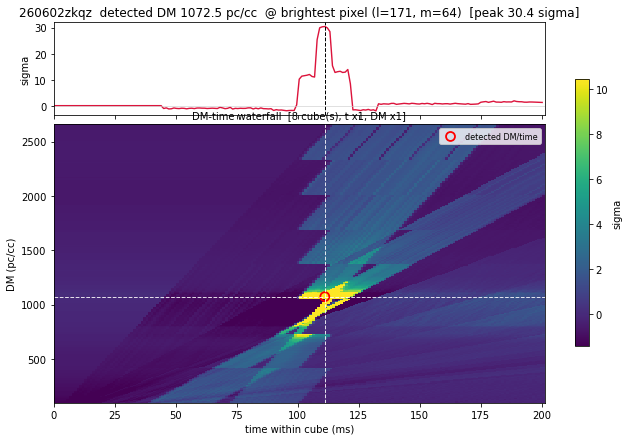

In [25]:
# =====================================================================
# Plot 3: detected-DM time series (top) + full-range DM-time waterfall
# =====================================================================
t_ms_full = np.arange(t_det) * sample_period_us / 1000.0

# ---- detected-DM time series at the brightest pixel (sigma) ---------
lc_det = np.asarray(cube[:, det_fdm, bright_lpix, bright_mpix], dtype=np.float32)
lc_det_sig = boxcar(baseline_sigma(lc_det, t_burst, LC_BASELINE_GUARD),
                    LC_SMOOTH_SAMPLES)

# ---- waterfall: apply DM range, optional sigma, then rebin ----------
dms = dm_full.copy()
M = M_full.copy()
if dm_full_known:
    sel = np.ones(dms.shape[0], dtype=bool)
    if WF_DM_MIN is not None:
        sel &= dms >= WF_DM_MIN
    if WF_DM_MAX is not None:
        sel &= dms <= WF_DM_MAX
    dms, M = dms[sel], M[sel]

if WF_SIGMA:
    M = np.stack([baseline_sigma(M[i], t_burst, LC_BASELINE_GUARD)
                  for i in range(M.shape[0])], axis=0)

dms_b, M_b = rebin_dm_time(dms, M, WF_DM_INTEGRATE, WF_T_INTEGRATE)
t_edges = np.arange(M_b.shape[1] + 1) * WF_T_INTEGRATE * sample_period_us / 1000.0

fig, (ax_ts, ax_wf) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    gridspec_kw={"height_ratios": [1, 3], "hspace": 0.05})

# Top panel: detected-DM light curve.
ax_ts.plot(t_ms_full, lc_det_sig, color="crimson", lw=1.4)
ax_ts.axvline(t_burst_ms, color="k", ls="--", lw=1.0)
ax_ts.axhline(0, color="0.8", lw=0.6)
ax_ts.set_ylabel("sigma")
ax_ts.set_title(f"{EVENT}  detected DM "
                f"{det_dm:.1f}{' pc/cc' if dm_known else ' (trial idx)'}  "
                f"@ brightest pixel (l={bright_lpix}, m={bright_mpix})  "
                f"[peak {np.nanmax(lc_det_sig):.1f} sigma]")
ax_ts.margins(x=0.02)

# Bottom panel: full-range DM-time waterfall.
vmin, vmax = np.nanpercentile(M_b, [2, 99.5])
if dm_full_known:
    dm_edges = centers_to_edges(dms_b)
    mesh = ax_wf.pcolormesh(t_edges, dm_edges, M_b, cmap=CMAP,
                            vmin=vmin, vmax=vmax, shading="flat")
    ax_wf.set_ylabel("DM (pc/cc)")
    y_det = det_dm
else:
    mesh = ax_wf.pcolormesh(t_edges, np.arange(M_b.shape[0] + 1), M_b,
                            cmap=CMAP, vmin=vmin, vmax=vmax, shading="flat")
    ax_wf.set_ylabel("fine-DM trial index")
    y_det = det_fdm
ax_wf.axvline(t_burst_ms, color="w", ls="--", lw=1.0, alpha=0.85)
ax_wf.axhline(y_det, color="w", ls="--", lw=1.0, alpha=0.85)
ax_wf.scatter([t_burst_ms], [y_det], marker="o", s=80, facecolors="none",
              edgecolors="red", linewidths=1.8, label="detected DM/time")
ax_wf.set_xlabel("time within cube (ms)")
ax_wf.set_title(f"DM-time waterfall  [{len(wf_paths)} cube(s), "
                f"t x{WF_T_INTEGRATE}, DM x{WF_DM_INTEGRATE}]", fontsize=10)
ax_wf.legend(loc="upper right", fontsize=8)
fig.colorbar(mesh, ax=[ax_ts, ax_wf],
             label=("sigma" if WF_SIGMA else "cube amplitude"), shrink=0.7)
plt.show()